In [1]:
seed = 43 # (42, 43, 111)

In [6]:
import pandas as pd
import os
from datasets import Dataset
os.chdir('/notebooks/EEVR')

In [9]:
text_data = pd.read_csv("Data_files/Textdata.csv")
text_data

,Text Description,Participant ID,Playlist ID,Video ID,Segment Name,CMA,Valence,Arousal
0,In this video childrens were shown whoes homes...,1,1,1,TheDisplaced,LVLA,4,3
1,In this video people and childrens were shown ...,1,1,2,HappyLand,LVLA,3,4
2,In this video a person who was confined in jai...,1,1,3,Jailbreak,LVHA,3,3
3,This video was about war and it impact all nat...,1,1,4,Warknownonation,LVHA,2,2
4,In this video I jumped into a canyon using a r...,1,1,5,CanyonSwing,HVHA,3,3
...,...,...,...,...,...,...,...,...
291,"This was a happy video, I felt very happy. I l...",40,4,4,PuppiesHost,HVHA,5,2
292,I felt motion sickness in this one. I was feel...,40,4,5,GreatOceanRoad,HVLA,3,2
293,After a minute or two I wanted to get out of t...,40,4,6,AbandonedBuilding,LVLA,3,2
294,This made me feel very bad. I did not feel lik...,40,4,7,NepalEarthquake,LVLA,2,4


In [ ]:
text_data.columns

In [13]:
from tqdm import tqdm
def label_prep(merged_df):
    vads = pd.read_csv("Data_files/VADS.csv") #getting label csv
    print("reading vad")

    #adding arousal, valence and dominance columns to orginal data csv
    for index, row in tqdm(merged_df.iterrows()):
        matching_rows = vads[(vads['Participant ID'] == row['Participant ID']) & (vads['Video ID'] == row['Video ID'])]

        if not matching_rows.empty:

            merged_df.at[index, 'Valence'] = matching_rows['Valence'].iloc[0]
            merged_df.at[index, 'Arousal'] = matching_rows['Arousal'].iloc[0]
            # merged_df.at[index, 'Dominance'] = matching_rows['Dominance'].iloc[0]
            # merged_df.at[index, 'significance'] = matching_rows['significance'].iloc[0]

    print("binning...")
    # Define the bins and labels for categorization
    bins = [1, 3, 5]  # Define the bin edges
    labels = [0, 1]   # Define the corresponding labels (0 (Low) for 1-3:, 1 (High) for 4-5)

    # Use the cut function to categorize the 'arousal' column
    merged_df['arousal_category'] = pd.cut(merged_df['Arousal'], bins=bins, labels=labels, include_lowest=True)
    merged_df['valence_category'] = pd.cut(merged_df['Valence'], bins=bins, labels=labels, include_lowest=True)

    # Convert the 'category' column to integer type if needed
    merged_df['arousal_category'] = merged_df['arousal_category'].astype(int)
    merged_df['valence_category'] = merged_df['valence_category'].astype(int)

    print("mapping")
    mapping = {
    'Baseline': 0,
    'LVLA': 0,
    'LVHA': 0,
    'HVHA': 1,
    'HVLA': 1  # Baseline and HVLA mapped to 0
    }

    # Apply the mapping to the 'CMA' column
    merged_df['taskwiselabel'] = merged_df['CMA'].map(mapping)
    # autofet_df

    # three_class_mapping = {
    # 'Baseline': 1,
    # 'LVLA': 1,
    # 'LVHA': 0,
    # 'HVHA': 1,
    # 'HVLA': 2
    # }

    # merged_df['three_class_label'] = merged_df['CMA'].map(three_class_mapping)
    return merged_df

text_data = label_prep(text_data)
text_data.to_csv("Data_files/text_data_labels.csv")


reading vad


296it [00:00, 2237.89it/s]

binning...
mapping


In [14]:
text_data = pd.read_csv("Data_files/text_data_labels.csv")
text_data

,Unnamed: 0,Text Description,Participant ID,Playlist ID,Video ID,Segment Name,CMA,Valence,Arousal,arousal_category,valence_category,taskwiselabel
0,0,In this video childrens were shown whoes homes...,1,1,1,TheDisplaced,LVLA,4,3,0,1,0
1,1,In this video people and childrens were shown ...,1,1,2,HappyLand,LVLA,3,4,1,0,0
2,2,In this video a person who was confined in jai...,1,1,3,Jailbreak,LVHA,3,3,0,0,0
3,3,This video was about war and it impact all nat...,1,1,4,Warknownonation,LVHA,2,2,0,0,0
4,4,In this video I jumped into a canyon using a r...,1,1,5,CanyonSwing,HVHA,3,3,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
291,291,"This was a happy video, I felt very happy. I l...",40,4,4,PuppiesHost,HVHA,5,2,0,1,1
292,292,I felt motion sickness in this one. I was feel...,40,4,5,GreatOceanRoad,HVLA,3,2,0,0,1
293,293,After a minute or two I wanted to get out of t...,40,4,6,AbandonedBuilding,LVLA,3,2,0,0,0
294,294,This made me feel very bad. I did not feel lik...,40,4,7,NepalEarthquake,LVLA,2,4,1,0,0


Pre-Processing and cleaning

In [15]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

def lowercase(data):
  temp  = data.lower()
  return temp

def stop_words(text):
  stop_words_set = set(stopwords.words('english'))
  word_tokens = word_tokenize(text)
  filtered_sentence = [word for word in word_tokens if word.lower() not in stop_words_set]
  return " ".join(filtered_sentence)

def punctuations(data):
  no_punct=[words for words in data if words not in string.punctuation]
  words_wo_punct=''.join(no_punct)
  return words_wo_punct

def lemmatize(text):
  lemmatizer = WordNetLemmatizer()
  word_tokens = word_tokenize(text)
  lemmatized_text = [lemmatizer.lemmatize(word) for word in word_tokens]
  return " ".join(lemmatized_text)

def preprcosess(text_data):
    text_data['Text'] = text_data['Text Description'].apply(lambda x: lemmatize(x))
    text_data['Text'] = text_data['Text'].apply(lambda x: stop_words(x))
    text_data['Text'] = text_data['Text'].apply(lambda x: lowercase(x))
    text_data['Text'] = text_data['Text'].apply(lambda x: punctuations(x))
    return text_data

text_data = preprcosess(text_data)
text_data

,Unnamed: 0,Text Description,Participant ID,Playlist ID,Video ID,Segment Name,CMA,Valence,Arousal,arousal_category,valence_category,taskwiselabel,Text
0,0,In this video childrens were shown whoes homes...,1,1,1,TheDisplaced,LVLA,4,3,0,1,0,video childrens shown whoes home destroyed war...
1,1,In this video people and childrens were shown ...,1,1,2,HappyLand,LVLA,3,4,1,0,0,video people childrens shown slum area video ...
2,2,In this video a person who was confined in jai...,1,1,3,Jailbreak,LVHA,3,3,0,0,0,video person wa confined jail run aways jail ...
3,3,This video was about war and it impact all nat...,1,1,4,Warknownonation,LVHA,2,2,0,0,0,video wa war impact nation equally video scen...
4,4,In this video I jumped into a canyon using a r...,1,1,5,CanyonSwing,HVHA,3,3,0,0,1,video jumped canyon using rope felt little sc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,291,"This was a happy video, I felt very happy. I l...",40,4,4,PuppiesHost,HVHA,5,2,0,1,1,wa happy video felt happy like puppy real li...
292,292,I felt motion sickness in this one. I was feel...,40,4,5,GreatOceanRoad,HVLA,3,2,0,0,1,felt motion sickness one wa feeling like lik...
293,293,After a minute or two I wanted to get out of t...,40,4,6,AbandonedBuilding,LVLA,3,2,0,0,0,minute two wanted get wanted video end wa ab...
294,294,This made me feel very bad. I did not feel lik...,40,4,7,NepalEarthquake,LVLA,2,4,1,0,0,made feel bad feel like wa wa third person p...


Wordcloud

In [21]:
! pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.3/551.3 kB 9.9 MB/s eta 0:00:00a 0:00:01


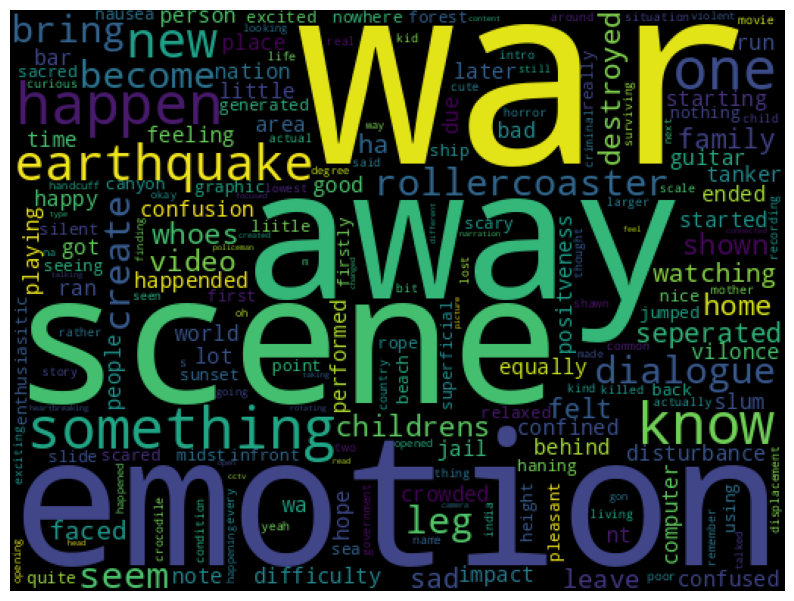

In [22]:
mCorpus=[]
for row in text_data['Text']:
      mCorpus.extend(row.split(" "))

wordfreq = {}
for word in mCorpus:
    if word not in wordfreq:
        wordfreq[word] = 0
    wordfreq[word] += 1

plt.figure(figsize=(10,10))
wordcloud = WordCloud(background_color="black",
                      width=512,
                      height=384,
                     ).generate(" ".join(wordfreq))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Model

Valence Distilbert

In [25]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# line 10 code should go in line 48 inside the for loop:this is the case of data leakage
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_valence = text_data[['Text','valence_category']]
vdataset = Dataset.from_pandas(text_valence)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_valence):
    train_df = text_valence.iloc[train_index]
    test_df = text_valence.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("valence_category", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("valence_category", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
    num_train_epochs=number_of_epochs,
    load_best_model_at_end=True,
    evaluation_strategy='steps',    # older version uses this name
    save_strategy='steps',
    report_to="none",
    learning_rate=2e-5,
    logging_steps=logging_steps,
    warmup_steps=warmup_steps,
    save_steps=1000,
    eval_steps=500,
    output_dir="fine-tuned-distilbert-base-uncased",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss


/tmp/ipykernel_96/32539832.py:27: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  load_accuracy = load_metric("accuracy")


...

Step,Training Loss,Validation Loss


Map:   0%|          | 0/237 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss


Average metrics over 5 folds: {'eval_loss': 0.19269509382138494, 'eval_accuracy': 0.9195480225988699, 'eval_f1score': 0.9192606201080779, 'eval_runtime': 1.0583, 'eval_samples_per_second': 56.9636, 'eval_steps_per_second': 3.8519999999999994, 'epoch': 7.0}


In [26]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# line 10 code should go in line 48 inside the for loop:this is the case of data leakage


# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_valence = text_data[['Text','valence_category']]
vdataset = Dataset.from_pandas(text_valence)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_valence):
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
    train_df = text_valence.iloc[train_index]
    test_df = text_valence.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("valence_category", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("valence_category", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
    num_train_epochs=number_of_epochs,
    load_best_model_at_end=True,
    evaluation_strategy='steps',    # older version uses this name
    save_strategy='steps',
    report_to="none",
    learning_rate=2e-5,
    logging_steps=logging_steps,
    warmup_steps=warmup_steps,
    save_steps=1000,
    eval_steps=500,
    output_dir="fine-tuned-distilbert-base-uncased",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/237 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss


Average metrics over 5 folds: {'eval_loss': 0.5966699123382568, 'eval_accuracy': 0.706045197740113, 'eval_f1score': 0.7027568182273345, 'eval_runtime': 1.0162, 'eval_samples_per_second': 58.327, 'eval_steps_per_second': 3.9415999999999998, 'epoch': 7.0}


Valence XLM-Bert

In [ ]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import XLMRobertaTokenizer, RobertaTokenizer, XLMRobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_valence = text_data[['Text','valence_category']]
vdataset = Dataset.from_pandas(text_valence)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_valence):
    train_df = text_valence.iloc[train_index]
    test_df = text_valence.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("valence_category", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("valence_category", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
        num_train_epochs=number_of_epochs,
        load_best_model_at_end=True,
        evaluation_strategy='steps',
        save_strategy='steps',
        learning_rate=2e-5,
        logging_steps=logging_steps,
        warmup_steps=warmup_steps,
        save_steps=1000,
        eval_steps=500,
        output_dir="fine-tuned-xlm-base-uncased",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)


Arousal Distilbert

In [ ]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_arousal = text_data[['Text','arousal_category']]
vdataset = Dataset.from_pandas(text_arousal)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_arousal):
    train_df = text_arousal.iloc[train_index]
    test_df = text_arousal.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("arousal_category", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("arousal_category", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
        num_train_epochs=number_of_epochs,
        load_best_model_at_end=True,
        evaluation_strategy='steps',
        save_strategy='steps',
        learning_rate=2e-5,
        logging_steps=logging_steps,
        warmup_steps=warmup_steps,
        save_steps=1000,
        eval_steps=500,
        output_dir="fine-tuned-distilbert-base-uncased",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)


Arousal XLMBert

In [ ]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import XLMRobertaTokenizer, RobertaTokenizer, XLMRobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_arousal = text_data[['Text','arousal_category']]
vdataset = Dataset.from_pandas(text_arousal)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_arousal):
    train_df = text_arousal.iloc[train_index]
    test_df = text_arousal.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("arousal_category", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("arousal_category", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
        num_train_epochs=number_of_epochs,
        load_best_model_at_end=True,
        evaluation_strategy='steps',
        save_strategy='steps',
        learning_rate=2e-5,
        logging_steps=logging_steps,
        warmup_steps=warmup_steps,
        save_steps=1000,
        eval_steps=500,
        output_dir="fine-tuned-xlm-base-uncased",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)


Taskwise Distilbert

In [ ]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'arousal_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_taskwiselabel = text_data[['Text','taskwiselabel']]
vdataset = Dataset.from_pandas(text_taskwiselabel)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_taskwiselabel):
    train_df = text_taskwiselabel.iloc[train_index]
    test_df = text_taskwiselabel.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("taskwiselabel", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("taskwiselabel", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
        num_train_epochs=number_of_epochs,
        load_best_model_at_end=True,
        evaluation_strategy='steps',
        save_strategy='steps',
        learning_rate=2e-5,
        logging_steps=logging_steps,
        warmup_steps=warmup_steps,
        save_steps=1000,
        eval_steps=500,
        output_dir="fine-tuned-distilbert-base-uncased",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)


Taskwise XLMBert

In [ ]:
import numpy as np
from datasets import load_metric, Dataset, DatasetDict
from transformers import XLMRobertaTokenizer, RobertaTokenizer, XLMRobertaForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold

# Initialize the tokenizer and model
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

# Load your dataset here
# For example, assuming text_valence is a pandas DataFrame with 'Text' and 'valence_category' columns
# vdataset = Dataset.from_pandas(text_valence)

# Example placeholder for the dataset, replace with your actual dataset
from datasets import Dataset
import pandas as pd

text_taskwiselabel = text_data[['Text','taskwiselabel']]
vdataset = Dataset.from_pandas(text_taskwiselabel)

# Define the tokenize function
def tokenize_function(examples):
    return tokenizer(examples['Text'], padding="max_length", truncation=True)

# Define the compute_metrics function
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)
    f1 = load_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": accuracy['accuracy'], "f1score": f1['f1']}

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare training arguments
batch_size = 16
number_of_epochs = 7

all_metrics = []

for train_index, test_index in kf.split(text_taskwiselabel):
    train_df = text_taskwiselabel.iloc[train_index]
    test_df = text_taskwiselabel.iloc[test_index]

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize datasets
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

    tokenized_train_dataset = tokenized_train_dataset.rename_column("taskwiselabel", "labels")
    tokenized_test_dataset = tokenized_test_dataset.rename_column("taskwiselabel", "labels")

    tokenized_train_dataset = tokenized_train_dataset.remove_columns(["Text"])
    tokenized_test_dataset = tokenized_test_dataset.remove_columns(["Text"])

    logging_steps = len(tokenized_train_dataset) // batch_size
    steps = (len(tokenized_train_dataset) / batch_size) * number_of_epochs
    warmup_steps = int(0.2 * steps)

    training_args = TrainingArguments(
        num_train_epochs=number_of_epochs,
        load_best_model_at_end=True,
        evaluation_strategy='steps',
        save_strategy='steps',
        learning_rate=2e-5,
        logging_steps=logging_steps,
        warmup_steps=warmup_steps,
        save_steps=1000,
        eval_steps=500,
        output_dir="fine-tuned-xlm-base-uncased",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()
    all_metrics.append(eval_results)

# Calculate average metrics
avg_metrics = {key: np.mean([metric[key] for metric in all_metrics]) for key in all_metrics[0]}
print("Average metrics over 5 folds:", avg_metrics)
